In [1]:
import os
print(os.getcwd())

/home/7e999635-eb70-4aaa-83b3-b876a4975b50


In [2]:
import os

for file in os.listdir():
    if "Metro" in file:
        print(file)

Metro_Interstate_Traffic_Volume.csv


In [3]:
import pandas as pd
import logging

logger = logging.getLogger(__name__)

try:
    df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
    logger.info("Traffic dataset loaded successfully.")
    logger.info("Dataset shape: %s", df.shape)
except FileNotFoundError:
    logger.error("Traffic CSV file was not found.")
    raise
except Exception as e:
    logger.error("Error loading traffic dataset: %s", e)
    raise

df.shape

(48204, 9)

In [4]:
#check columns
required_columns = [
    "holiday",
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "weather_main",
    "weather_description",
    "date_time",
    "traffic_volume"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    logger.error("Missing required columns: %s", missing_columns)
    raise ValueError(f"Missing required columns: {missing_columns}")
else:
    logger.info("Schema validation passed. All required columns are present.")

df.columns.tolist()

['holiday',
 'temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'weather_main',
 'weather_description',
 'date_time',
 'traffic_volume']

In [5]:
# Parse and validate date/time

df["date_time"] = pd.to_datetime(
    df["date_time"],
    dayfirst=True,
    errors="coerce"
)

invalid_dates = df["date_time"].isna().sum()

if invalid_dates > 0:
    logger.warning(
        "%d invalid date/time values were found.",
        invalid_dates
    )
else:
    logger.info("All date/time values parsed successfully.")

invalid_dates

0

In [6]:
# Check for duplicate rows and duplicate date/time values

duplicate_rows = df.duplicated().sum()
duplicate_times = df["date_time"].duplicated().sum()

logger.info("Number of fully duplicated rows: %d", duplicate_rows)
logger.info("Number of repeated date/time values: %d", duplicate_times)

duplicate_rows, duplicate_times

(17, 7629)

In [7]:
# Remove fully duplicated rows

rows_before = len(df)

df = df.drop_duplicates().copy()

rows_after = len(df)
rows_removed = rows_before - rows_after

logger.info("Removed %d fully duplicated rows.", rows_removed)

rows_before, rows_after, rows_removed

(48204, 48187, 17)

In [8]:
# Check continuous variables for impossible or extreme values

df[["temp", "rain_1h", "snow_1h", "clouds_all", "traffic_volume"]].describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000
mean,281.204995,0.334382,0.000222,49.365451,3259.618134
std,13.338738,44.797033,0.008169,39.015213,1986.954465
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1192.500000
50%,282.450000,0.000000,0.000000,64.000000,3379.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [9]:
# Count impossible temperature and rainfall values

zero_temp_count = (df["temp"] == 0).sum()
extreme_rain_count = (df["rain_1h"] > 500).sum()

logger.info("Number of records with temperature = 0 K: %d", zero_temp_count)
logger.info("Number of records with rainfall > 500 mm: %d", extreme_rain_count)

zero_temp_count, extreme_rain_count

(10, 1)

In [10]:
# Inspect records with impossible temperature or extreme rainfall

df.loc[
    (df["temp"] == 0) | (df["rain_1h"] > 500),
    ["date_time", "temp", "rain_1h", "weather_main",
     "weather_description", "traffic_volume"]
]

,date_time,temp,rain_1h,weather_main,weather_description,traffic_volume
11898,2014-01-31 03:00:00,0.00,0.0,Clear,sky is clear,361
11899,2014-01-31 04:00:00,0.00,0.0,Clear,sky is clear,734
11900,2014-01-31 05:00:00,0.00,0.0,Clear,sky is clear,2557
11901,2014-01-31 06:00:00,0.00,0.0,Clear,sky is clear,5150
11946,2014-02-02 03:00:00,0.00,0.0,Clear,sky is clear,291
11947,2014-02-02 04:00:00,0.00,0.0,Clear,sky is clear,284
11948,2014-02-02 05:00:00,0.00,0.0,Clear,sky is clear,434
11949,2014-02-02 06:00:00,0.00,0.0,Clear,sky is clear,739
11950,2014-02-02 07:00:00,0.00,0.0,Clear,sky is clear,962
11951,2014-02-02 08:00:00,0.00,0.0,Clear,sky is clear,1670


In [11]:
# finding the highest hourly rainfall values

df.nlargest(
    10,
    "rain_1h"
)[["date_time", "rain_1h", "weather_main",
   "weather_description", "traffic_volume"]]

,date_time,rain_1h,weather_main,weather_description,traffic_volume
24872,2016-07-11 17:00:00,9831.30,Rain,very heavy rain,5535
8247,2013-08-07 02:00:00,55.63,Rain,very heavy rain,315
7179,2013-06-24 11:00:00,44.45,Rain,very heavy rain,4802
25779,2016-08-16 17:00:00,31.75,Rain,very heavy rain,4913
10806,2013-12-19 23:00:00,28.70,Rain,very heavy rain,1190
10807,2013-12-19 23:00:00,28.70,Snow,light snow,1190
16504,2015-07-13 00:00:00,27.57,Rain,very heavy rain,492
16505,2015-07-13 00:00:00,27.57,Thunderstorm,proximity thunderstorm,492
16506,2015-07-13 00:00:00,27.57,Mist,mist,492
17437,2015-08-16 21:00:00,25.46,Rain,very heavy rain,2118


In [12]:
# Replace confirmed erroneous values with missing values

import numpy as np

df.loc[df["temp"] == 0, "temp"] = np.nan
df.loc[df["rain_1h"] == 9831.3, "rain_1h"] = np.nan

logger.warning("Replaced 10 impossible temperature values (0 K) with NaN.")
logger.warning("Replaced erroneous rainfall value (9831.3 mm) with NaN.")

df[["temp", "rain_1h"]].isna().sum()

Replaced 10 impossible temperature values (0 K) with NaN.
Replaced erroneous rainfall value (9831.3 mm) with NaN.


temp       10
rain_1h     1
dtype: int64

In [13]:
# Recheck statistics after removing erroneous values

df[["temp", "rain_1h"]].describe()

,temp,rain_1h
count,48177.000000,48186.000000
mean,281.263364,0.130361
std,12.709895,1.003552
min,243.390000,0.000000
25%,272.180000,0.000000
50%,282.460000,0.000000
75%,291.810000,0.000000
max,310.070000,55.630000


In [14]:
# Filling in missing temperature values using time interpolation (averaging between adjacent values)

df = df.sort_values("date_time").copy()

df["temp"] = df["temp"].interpolate(method="linear")

logger.info("Missing temperature values imputed using linear interpolation.")

df["temp"].isna().sum()

0

In [15]:
# Show temperatures around the missing temperature values

missing_times = df.loc[df["temp"].isna(), "date_time"]

for time in missing_times:
    nearby = df.loc[
        (df["date_time"] >= time - pd.Timedelta(hours=2)) &
        (df["date_time"] <= time + pd.Timedelta(hours=2)),
        ["date_time", "temp", "weather_main", "traffic_volume"]
    ]
    
    print("\nMissing temperature at:", time)
    display(nearby)

In [17]:
# Show rows around the missing temperature values

df = df.sort_values("date_time").reset_index(drop=True)

missing_rows = df[df["temp"].isna()].index

for i in missing_rows:
    print(df.loc[max(0, i-2):i+2, ["date_time", "temp"]])
    print()

In [18]:
# Check how many missing temperature values remain

df["temp"].isna().sum()

0

In [19]:
# Check the temperatures around the values that were filled

df.loc[
    (df["date_time"] >= "2014-01-31 01:00") &
    (df["date_time"] <= "2014-02-02 10:00"),
    ["date_time", "temp"]
]

,date_time,temp
11896,2014-01-31 01:00:00,255.930000
11897,2014-01-31 02:00:00,255.930000
11898,2014-01-31 03:00:00,255.930000
11899,2014-01-31 04:00:00,255.930000
11900,2014-01-31 05:00:00,255.930000
11901,2014-01-31 06:00:00,255.930000
11902,2014-01-31 07:00:00,255.930000
11903,2014-01-31 08:00:00,255.930000
11904,2014-01-31 09:00:00,255.930000
11905,2014-01-31 10:00:00,255.840000


In [20]:
# Check other weather records at the same time as the erroneous rainfall value

df.loc[
    df["date_time"] == "2016-07-11 17:00",
    ["date_time", "rain_1h", "weather_main",
     "weather_description", "traffic_volume"]
]

,date_time,rain_1h,weather_main,weather_description,traffic_volume
24870,2016-07-11 17:00:00,NaN,Rain,very heavy rain,5535


In [21]:
# Check remaining missing values

df.isna().sum()

holiday                48126
temp                       0
rain_1h                    1
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [22]:
# Check how pandas reads the holiday column without automatic NA conversion

test_df = pd.read_csv(
    "Metro_Interstate_Traffic_Volume.csv",
    keep_default_na=False
)

test_df["holiday"].value_counts().head(10)

holiday
None                         48143
Labor Day                        7
Christmas Day                    6
Thanksgiving Day                 6
Martin Luther King Jr Day        6
New Years Day                    6
Veterans Day                     5
Columbus Day                     5
Memorial Day                     5
Washingtons Birthday             5
Name: count, dtype: int64

In [24]:
df["holiday"] = df["holiday"].fillna("None")

logger.info("Non-holiday records restored to the 'None' category.")

df.isna().sum()

holiday                0
temp                   0
rain_1h                1
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64

In [25]:
# Standardize categorical text values

categorical_columns = [
    "holiday",
    "weather_main",
    "weather_description"
]

for column in categorical_columns:
    df[column] = df[column].str.strip()

logger.info("Categorical text values standardized.")

In [26]:
# Check standardized categorical values

df[["holiday", "weather_main", "weather_description"]].head(10)

,holiday,weather_main,weather_description
0,None,Clouds,scattered clouds
1,None,Clouds,broken clouds
2,None,Clouds,overcast clouds
3,None,Clouds,overcast clouds
4,None,Clouds,broken clouds
5,None,Clear,sky is clear
6,None,Clear,sky is clear
7,None,Clear,sky is clear
8,None,Clouds,few clouds
9,None,Clouds,few clouds


In [27]:
# Validate numerical ranges after cleaning

range_checks = {
    "temp_below_0K": (df["temp"] < 0).sum(),
    "negative_rain": (df["rain_1h"] < 0).sum(),
    "negative_snow": (df["snow_1h"] < 0).sum(),
    "invalid_clouds": ((df["clouds_all"] < 0) | (df["clouds_all"] > 100)).sum(),
    "negative_traffic": (df["traffic_volume"] < 0).sum()
}

range_checks

{'temp_below_0K': 0,
 'negative_rain': 0,
 'negative_snow': 0,
 'invalid_clouds': 0,
 'negative_traffic': 0}

In [1]:
# Create time-based features from date_time

df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.day_name()
df["is_weekend"] = df["date_time"].dt.dayofweek.isin([5, 6]).astype(int)

df[["date_time", "hour", "day_of_week", "is_weekend"]].head(10)

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2/10/2012 9:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2/10/2012 10:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2/10/2012 11:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2/10/2012 12:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2/10/2012 13:00,4918


In [4]:
# Convert date_time to datetime
df["date_time"] = pd.to_datetime(df["date_time"], dayfirst=True)

# Create time-based features
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.day_name()
df["is_weekend"] = df["date_time"].dt.dayofweek.isin([5, 6]).astype(int)

df[["date_time", "hour", "day_of_week", "is_weekend"]].head(10)


,date_time,hour,day_of_week,is_weekend
0,2012-10-02 09:00:00,9,Tuesday,0
1,2012-10-02 10:00:00,10,Tuesday,0
2,2012-10-02 11:00:00,11,Tuesday,0
3,2012-10-02 12:00:00,12,Tuesday,0
4,2012-10-02 13:00:00,13,Tuesday,0
5,2012-10-02 14:00:00,14,Tuesday,0
6,2012-10-02 15:00:00,15,Tuesday,0
7,2012-10-02 16:00:00,16,Tuesday,0
8,2012-10-02 17:00:00,17,Tuesday,0
9,2012-10-02 18:00:00,18,Tuesday,0


In [5]:
# Create traffic category
def traffic_category(volume):
    if volume < 4500:
        return "Low"
    elif volume <= 5500:
        return "Medium"
    else:
        return "High"

df["traffic_category"] = df["traffic_volume"].apply(traffic_category)

df[["traffic_volume", "traffic_category"]].head(10)

,traffic_volume,traffic_category
0,5545,High
1,4516,Medium
2,4767,Medium
3,5026,Medium
4,4918,Medium
5,5181,Medium
6,5584,High
7,6015,High
8,5791,High
9,4770,Medium


In [6]:
# Convert temperature from Kelvin to Celsius
df["temperature_c"] = df["temp"] - 273.15

df[["temp", "temperature_c"]].head(10)

,temp,temperature_c
0,288.28,15.13
1,289.36,16.21
2,289.58,16.43
3,290.13,16.98
4,291.14,17.99
5,291.72,18.57
6,293.17,20.02
7,293.86,20.71
8,294.14,20.99
9,293.10,19.95


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     object        
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   date_time            48204 non-null  datetime64[ns]
 8   traffic_volume       48204 non-null  int64         
 9   hour                 48204 non-null  int32         
 10  day_of_week          48204 non-null  object        
 11  is_weekend           48204 non-null  int64         
 12  traffic_category     48204 non-null  object        
 13  temperature_c        48204 non-

In [8]:
# Check exact duplicate rows
print("Total rows:", len(df))
print("Exact duplicate rows:", df.duplicated().sum())

# Check duplicated date/time values
print("Duplicated date_time values:", df["date_time"].duplicated().sum())
print("Unique date_time values:", df["date_time"].nunique())

Total rows: 48204
Exact duplicate rows: 17
Duplicated date_time values: 7629
Unique date_time values: 40575


In [9]:
df_clean = df.drop_duplicates(subset=["date_time"]).copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))

Original rows: 48204
Cleaned rows: 40575


In [10]:
# Show rows with duplicated timestamps
dup_times = df[df.duplicated(subset=["date_time"], keep=False)]

dup_times.sort_values("date_time").head(20)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,is_weekend,traffic_category,temperature_c
178,NaN,281.25,0.0,0.0,99,Rain,light rain,2012-10-10 07:00:00,6793,7,Wednesday,0,High,8.10
179,NaN,281.25,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 07:00:00,6793,7,Wednesday,0,High,8.10
180,NaN,280.10,0.0,0.0,99,Rain,light rain,2012-10-10 08:00:00,6283,8,Wednesday,0,High,6.95
181,NaN,280.10,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 08:00:00,6283,8,Wednesday,0,High,6.95
182,NaN,279.61,0.0,0.0,99,Rain,light rain,2012-10-10 09:00:00,5680,9,Wednesday,0,High,6.46
183,NaN,279.61,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 09:00:00,5680,9,Wednesday,0,High,6.46
269,NaN,282.43,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 09:00:00,2685,9,Sunday,1,Low,9.28
270,NaN,282.43,0.0,0.0,57,Mist,mist,2012-10-14 09:00:00,2685,9,Sunday,1,Low,9.28
271,NaN,282.43,0.0,0.0,57,Haze,haze,2012-10-14 09:00:00,2685,9,Sunday,1,Low,9.28
272,NaN,282.33,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 10:00:00,3370,10,Sunday,1,Low,9.18


In [11]:
# How many weather records are attached to each timestamp?
records_per_time = df.groupby("date_time").size()

print(records_per_time.value_counts().sort_index())
print("\nMaximum records for one timestamp:", records_per_time.max())

1    35130
2     3617
3     1513
4      276
5       37
6        2
Name: count, dtype: int64

Maximum records for one timestamp: 6


In [12]:
# Check whether any timestamp has more than one traffic volume
traffic_check = df.groupby("date_time")["traffic_volume"].nunique()

print("Timestamps with different traffic volumes:",
      (traffic_check > 1).sum())

Timestamps with different traffic volumes: 0


In [13]:
# Keep one traffic observation per timestamp
df_clean = df.drop_duplicates(subset=["date_time"]).copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 48204
Cleaned rows: 40575
Rows removed: 7629


In [14]:
df_traffic = df_clean

In [15]:
# Calculate average traffic volume for each hour of the day
hourly_traffic = df_traffic.groupby("hour")["traffic_volume"].mean()

hourly_traffic

hour
0      844.854324
1      521.318713
2      392.637006
3      373.210306
4      701.317675
5     2103.667062
6     4172.058229
7     4769.831340
8     4593.599763
9     4394.778523
10    4204.876833
11    4498.458908
12    4739.118794
13    4741.578004
14    4957.022982
15    5271.737823
16    5708.614528
17    5350.830529
18    4306.467301
19    3311.021390
20    2869.703920
21    2699.360915
22    2224.418848
23    1490.710345
Name: traffic_volume, dtype: float64

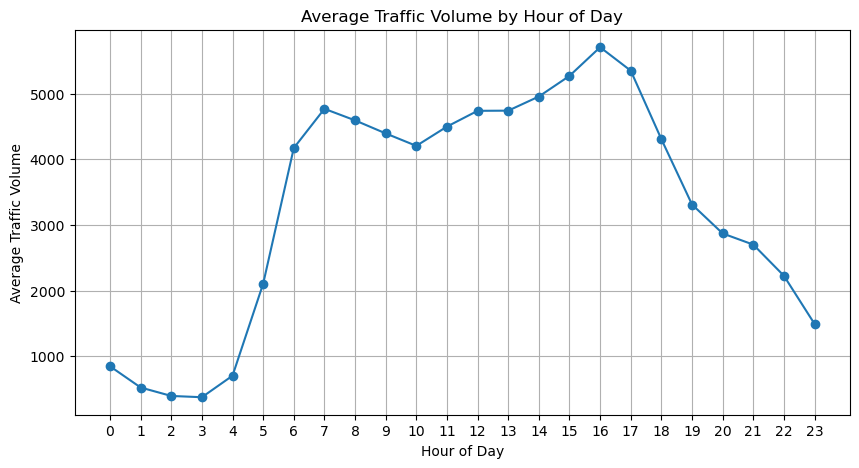

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(hourly_traffic.index, hourly_traffic.values, marker="o")

plt.title("Average Traffic Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(0,24))
plt.grid(True)

plt.show()

In [17]:
# Compare average traffic volume on weekdays and weekends
weekend_traffic = df_traffic.groupby("is_weekend")["traffic_volume"].mean()

weekend_traffic.index = ["Weekday", "Weekend"]

weekend_traffic

Weekday    3557.440457
Weekend    2623.928596
Name: traffic_volume, dtype: float64

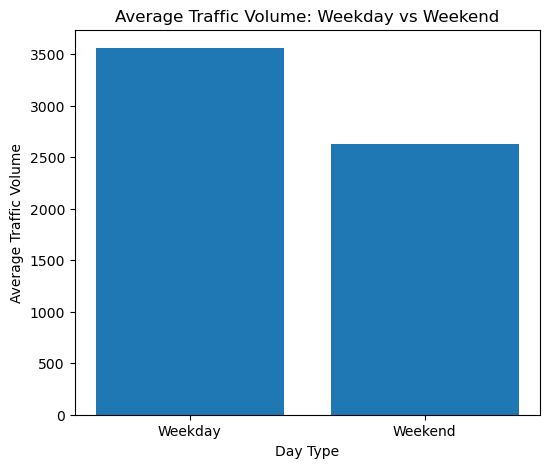

In [18]:
plt.figure(figsize=(6,5))
plt.bar(weekend_traffic.index, weekend_traffic.values)

plt.title("Average Traffic Volume: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Traffic Volume")

plt.show()

In [19]:
# Average traffic by hour for weekdays and weekends
hourly_daytype = (
    df_traffic.groupby(["hour", "is_weekend"])["traffic_volume"]
    .mean()
    .unstack()
)

hourly_daytype.columns = ["Weekday", "Weekend"]

hourly_daytype.head()

,Weekday,Weekend
hour,,
0,655.215559,1323.411043
1,400.186161,817.800403
2,303.099343,620.313152
3,362.868003,399.438559
4,830.107084,381.582822


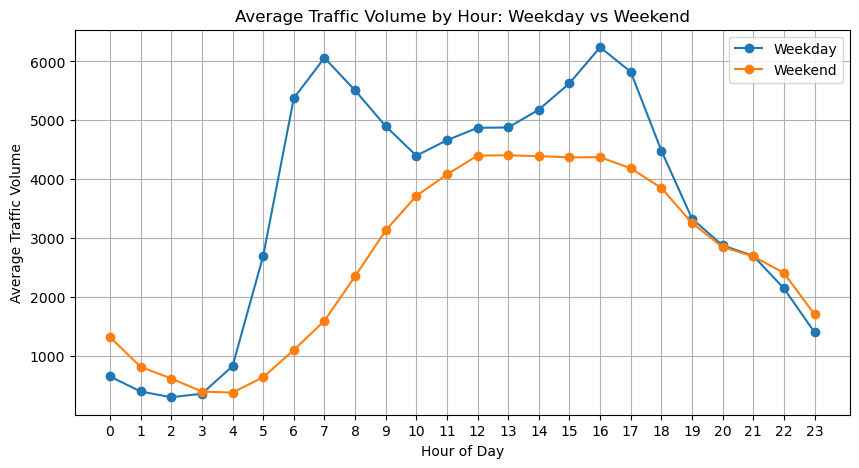

In [20]:
plt.figure(figsize=(10,5))

plt.plot(hourly_daytype.index, hourly_daytype["Weekday"],
         marker="o", label="Weekday")

plt.plot(hourly_daytype.index, hourly_daytype["Weekend"],
         marker="o", label="Weekend")

plt.title("Average Traffic Volume by Hour: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(0,24))
plt.legend()
plt.grid(True)

plt.show()

In [21]:
# Average traffic volume by day of week
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_traffic = (
    df_traffic.groupby("day_of_week")["traffic_volume"]
    .mean()
    .reindex(day_order)
)

daily_traffic

day_of_week
Monday       3313.560614
Tuesday      3534.717166
Wednesday    3608.276064
Thursday     3653.914611
Friday       3674.777608
Saturday     2822.564661
Sunday       2426.249484
Name: traffic_volume, dtype: float64

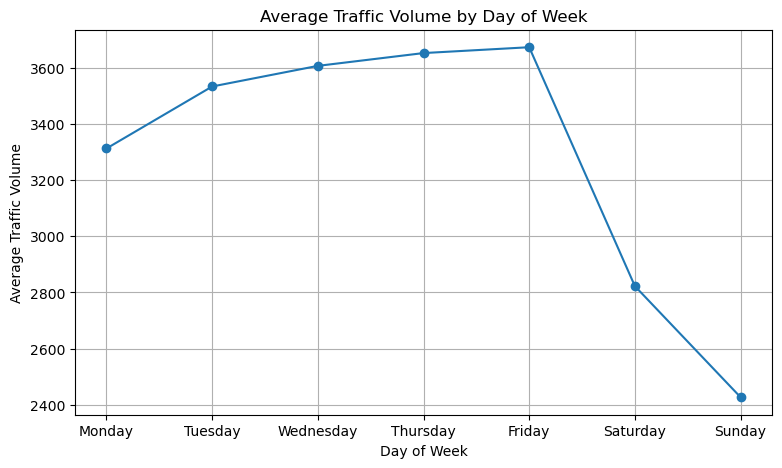

In [22]:
plt.figure(figsize=(9,5))

plt.plot(daily_traffic.index, daily_traffic.values, marker="o")

plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Traffic Volume")
plt.grid(True)

plt.show()

In [23]:
# Correlation between temperature and traffic volume
temp_corr = df_traffic["temperature_c"].corr(
    df_traffic["traffic_volume"]
)

print("Correlation between temperature and traffic volume:", temp_corr)

Correlation between temperature and traffic volume: 0.13692361981610202


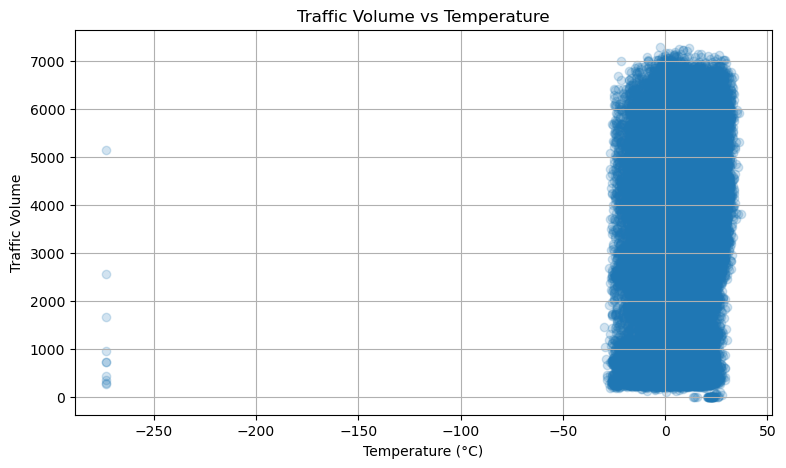

In [24]:
plt.figure(figsize=(9,5))

plt.scatter(
    df_traffic["temperature_c"],
    df_traffic["traffic_volume"],
    alpha=0.2
)

plt.title("Traffic Volume vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Traffic Volume")
plt.grid(True)

plt.show()

In [25]:
# Check implausible temperatures
bad_temp = df_traffic[df_traffic["temperature_c"] < -50]

print("Number of implausible temperature records:", len(bad_temp))

bad_temp[["date_time", "temp", "temperature_c", "traffic_volume"]].head(10)

Number of implausible temperature records: 10


,date_time,temp,temperature_c,traffic_volume
11898,2014-01-31 03:00:00,0.0,-273.15,361
11899,2014-01-31 04:00:00,0.0,-273.15,734
11900,2014-01-31 05:00:00,0.0,-273.15,2557
11901,2014-01-31 06:00:00,0.0,-273.15,5150
11946,2014-02-02 03:00:00,0.0,-273.15,291
11947,2014-02-02 04:00:00,0.0,-273.15,284
11948,2014-02-02 05:00:00,0.0,-273.15,434
11949,2014-02-02 06:00:00,0.0,-273.15,739
11950,2014-02-02 07:00:00,0.0,-273.15,962
11951,2014-02-02 08:00:00,0.0,-273.15,1670


In [26]:
# Create clean dataset for temperature analysis only
df_temp = df_traffic[df_traffic["temperature_c"] > -50].copy()

print("Traffic records:", len(df_traffic))
print("Valid temperature records:", len(df_temp))

# Recalculate correlation
temp_corr_clean = df_temp["temperature_c"].corr(df_temp["traffic_volume"])

print("Cleaned temperature correlation:", temp_corr_clean)

Traffic records: 40575
Valid temperature records: 40565
Cleaned temperature correlation: 0.13926839718160128


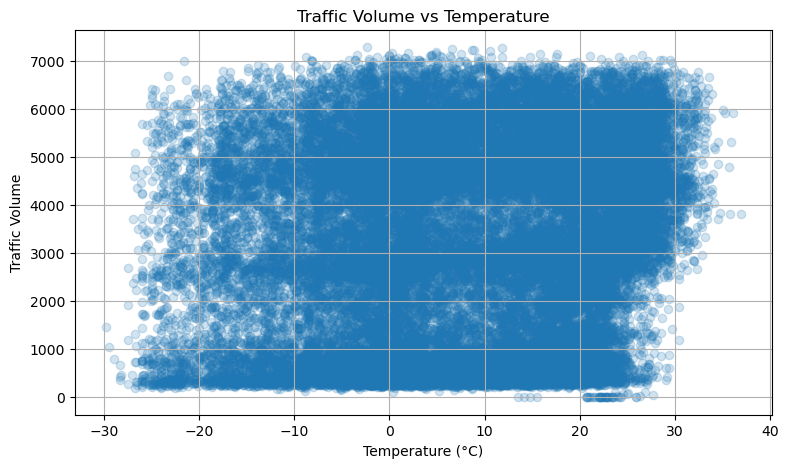

In [27]:
plt.figure(figsize=(9,5))

plt.scatter(
    df_temp["temperature_c"],
    df_temp["traffic_volume"],
    alpha=0.2
)

plt.title("Traffic Volume vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Traffic Volume")
plt.grid(True)

plt.show()

In [28]:
# Check weather categories and number of records
df["weather_main"].value_counts()

weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [30]:
# Create one weather record per timestamp
weather_traffic = (
    df.sort_values("date_time")
      .drop_duplicates(subset="date_time")
      [["date_time", "weather_main", "traffic_volume"]]
      .copy()
)

print("Number of unique timestamps:", len(weather_traffic))

# Average traffic volume by weather condition
weather_avg = (
    weather_traffic.groupby("weather_main")["traffic_volume"]
    .mean()
    .sort_values(ascending=False)
)

weather_avg



Number of unique timestamps: 40575


weather_main
Clouds          3616.915939
Haze            3572.186747
Rain            3360.728647
Drizzle         3256.201460
Clear           3055.462563
Snow            3029.348289
Thunderstorm    3007.505155
Mist            2859.950774
Fog             2666.080128
Smoke           2447.000000
Squall           410.000000
Name: traffic_volume, dtype: float64

In [31]:
# Count observations for each weather category
weather_counts = weather_traffic["weather_main"].value_counts()

# Keep weather categories with at least 100 observations
common_weather = weather_counts[weather_counts >= 100].index

weather_avg_common = (
    weather_traffic[
        weather_traffic["weather_main"].isin(common_weather)
    ]
    .groupby("weather_main")["traffic_volume"]
    .mean()
    .sort_values(ascending=False)
)

weather_avg_common

weather_main
Clouds          3616.915939
Haze            3572.186747
Rain            3360.728647
Drizzle         3256.201460
Clear           3055.462563
Snow            3029.348289
Thunderstorm    3007.505155
Mist            2859.950774
Fog             2666.080128
Name: traffic_volume, dtype: float64

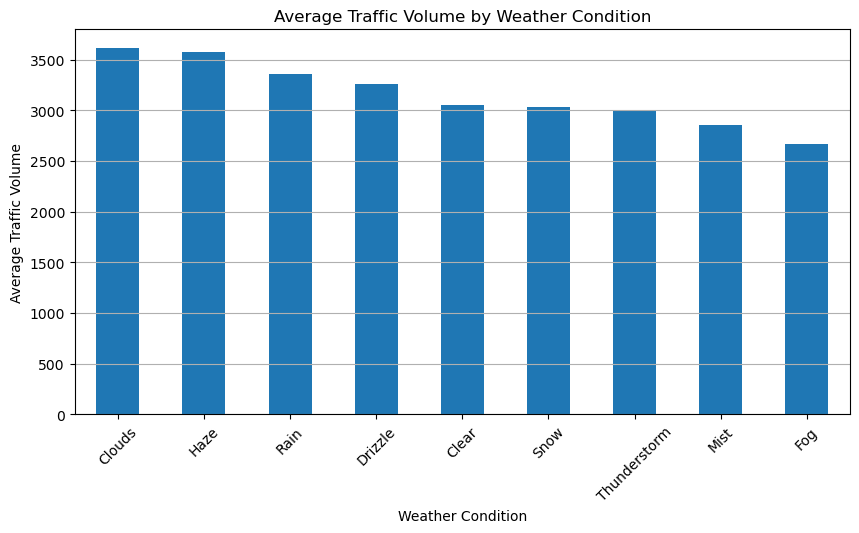

In [32]:
plt.figure(figsize=(10,5))

weather_avg_common.plot(kind="bar")

plt.title("Average Traffic Volume by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Traffic Volume")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [33]:
# Examine rare weather conditions individually
rare_weather = weather_traffic[
    weather_traffic["weather_main"].isin(["Squall", "Smoke"])
].copy()

rare_weather["hour"] = rare_weather["date_time"].dt.hour

rare_weather[
    ["date_time", "hour", "weather_main", "traffic_volume"]
].sort_values(["weather_main", "date_time"])

,date_time,hour,weather_main,traffic_volume
16348,2015-07-06 18:00:00,18,Smoke,4264
16350,2015-07-06 19:00:00,19,Smoke,3040
16352,2015-07-06 20:00:00,20,Smoke,2561
23091,2016-05-07 01:00:00,1,Smoke,890
23093,2016-05-07 02:00:00,2,Smoke,630
23095,2016-05-07 03:00:00,3,Smoke,420
23097,2016-05-07 04:00:00,4,Smoke,367
23101,2016-05-07 06:00:00,6,Smoke,1347
23103,2016-05-07 07:00:00,7,Smoke,2182
23105,2016-05-07 08:00:00,8,Smoke,3139


In [34]:
# Check all original Squall records
squall_records = df[df["weather_main"] == "Squall"]

print("Squall rows:", len(squall_records))
print("Unique Squall timestamps:", squall_records["date_time"].nunique())

squall_records[
    ["date_time", "weather_main", "weather_description", "traffic_volume"]
].sort_values("date_time")

Squall rows: 4
Unique Squall timestamps: 4


,date_time,weather_main,weather_description,traffic_volume
5958,2013-05-12 02:00:00,Squall,SQUALLS,420
7132,2013-06-22 04:00:00,Squall,SQUALLS,400
8261,2013-08-07 20:00:00,Squall,SQUALLS,3216
25287,2016-07-27 14:00:00,Squall,SQUALLS,4211


In [35]:
# Examine ALL Smoke and Squall records from original data
rare_weather = df[
    df["weather_main"].isin(["Squall", "Smoke"])
].copy()

rare_weather["hour"] = rare_weather["date_time"].dt.hour

rare_weather[
    ["date_time", "hour", "weather_main",
     "weather_description", "traffic_volume"]
].sort_values(["weather_main", "date_time"])

,date_time,hour,weather_main,weather_description,traffic_volume
16330,2015-07-06 13:00:00,13,Smoke,smoke,4307
16335,2015-07-06 14:00:00,14,Smoke,smoke,4888
16339,2015-07-06 15:00:00,15,Smoke,smoke,5205
16343,2015-07-06 16:00:00,16,Smoke,smoke,6006
16346,2015-07-06 17:00:00,17,Smoke,smoke,5861
16348,2015-07-06 18:00:00,18,Smoke,smoke,4264
16350,2015-07-06 19:00:00,19,Smoke,smoke,3040
16352,2015-07-06 20:00:00,20,Smoke,smoke,2561
23091,2016-05-07 01:00:00,1,Smoke,smoke,890
23093,2016-05-07 02:00:00,2,Smoke,smoke,630


In [40]:
# Compare each Squall observation with normal average traffic at the same hour

squall_compare = df[df["weather_main"] == "Squall"][
    ["date_time", "traffic_volume"]
].copy()

squall_compare["hour"] = squall_compare["date_time"].dt.hour

# Normal average traffic for each hour from cleaned traffic data
normal_by_hour = df_traffic.groupby("hour")["traffic_volume"].mean()

squall_compare["normal_avg_same_hour"] = (
    squall_compare["hour"].map(normal_by_hour)
)
squall_compare["difference"] = (
    squall_compare["traffic_volume"] -
    squall_compare["normal_avg_same_hour"]
)

squall_compare["percent_difference"] = (
    squall_compare["difference"] /
    squall_compare["normal_avg_same_hour"] * 100
)

squall_compare

,date_time,traffic_volume,hour,normal_avg_same_hour,difference,percent_difference
5958,2013-05-12 02:00:00,420,2,392.637006,27.362994,6.969031
7132,2013-06-22 04:00:00,400,4,701.317675,-301.317675,-42.964506
8261,2013-08-07 20:00:00,3216,20,2869.703920,346.296080,12.067310
25287,2016-07-27 14:00:00,4211,14,4957.022982,-746.022982,-15.049819


In [41]:
%run pipeline.py

2026-09-24 15:17:25,658 - INFO - __main__ - Starting traffic data pipeline.
2026-09-24 15:17:25,727 - INFO - __main__ - Data loaded successfully: 48204 rows and 9 columns
2026-09-24 15:17:25,728 - INFO - __main__ - Schema validation successful.
2026-09-24 15:17:25,768 - INFO - __main__ - Removed 17 exact duplicate rows.
2026-09-24 15:17:25,899 - INFO - __main__ - date_time converted to datetime format.
2026-09-24 15:17:25,900 - WARNING - __main__ - Found 10 invalid temperature values.
2026-09-24 15:17:25,903 - INFO - __main__ - Imputed 10 missing temperature values with median 282.46 K.
2026-09-24 15:17:25,904 - INFO - __main__ - Basic data cleaning completed.
2026-09-24 15:17:25,904 - INFO - __main__ - Data cleaning finished. Final dataset contains 48187 rows.
2026-09-24 15:17:25,905 - INFO - __main__ - Traffic data pipeline completed successfully.


In [42]:
%run feature_engineering.py

In [43]:
df_features = engineer_features(df_clean)

df_features[
    [
        "hour",
        "day_of_week",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "temp_scaled",
        "clouds_all_scaled",
        "traffic_category"
    ]
].head()

2026-09-24 15:38:04,518 - INFO - __main__ - Starting feature engineering.
2026-09-24 15:38:04,537 - INFO - __main__ - Created hour, day_of_week and is_weekend features.
2026-09-24 15:38:04,541 - INFO - __main__ - Created cyclical hour features: hour_sin and hour_cos.
2026-09-24 15:38:04,563 - INFO - __main__ - One-hot encoded weather_main into 11 weather features.
2026-09-24 15:38:04,569 - INFO - __main__ - Standardised continuous variable: temp.
2026-09-24 15:38:04,571 - INFO - __main__ - Standardised continuous variable: clouds_all.
2026-09-24 15:38:04,576 - INFO - __main__ - Created data-driven traffic congestion categories using tertiles.


,hour,day_of_week,is_weekend,hour_sin,hour_cos,temp_scaled,clouds_all_scaled,traffic_category
0,9,Tuesday,0,7.071068e-01,-0.707107,0.552098,-0.240046,High
1,10,Tuesday,0,5.000000e-01,-0.866025,0.637080,0.657040,Medium
2,11,Tuesday,0,2.588190e-01,-0.965926,0.654391,1.041505,High
3,12,Tuesday,0,1.224647e-16,-1.000000,0.697669,1.041505,High
4,13,Tuesday,0,-2.588190e-01,-0.965926,0.777143,0.657040,High


In [44]:
%run visualizations.py

In [45]:
create_visualizations(df_features)

2026-09-24 15:48:33,396 - INFO - __main__ - Starting visualisation generation.
2026-09-24 15:48:33,627 - INFO - __main__ - Saved visualisation: figures/traffic_by_hour.png
2026-09-24 15:48:33,885 - INFO - __main__ - Saved visualisation: figures/weekday_vs_weekend_by_hour.png
2026-09-24 15:48:34,064 - INFO - __main__ - Saved visualisation: figures/traffic_by_day_of_week.png
2026-09-24 15:48:34,065 - INFO - __main__ - Visualisation generation completed.


In [46]:
%run traffic_app.py

2026-09-24 16:03:27,514 - INFO - __main__ - Starting Traffic Query App.
2026-09-24 16:03:27,636 - INFO - pipeline - Data loaded successfully: 48204 rows and 9 columns
2026-09-24 16:03:27,641 - INFO - pipeline - Schema validation successful.
2026-09-24 16:03:27,693 - INFO - pipeline - Removed 17 exact duplicate rows.
2026-09-24 16:03:27,930 - INFO - pipeline - date_time converted to datetime format.
2026-09-24 16:03:27,932 - WARNING - pipeline - Found 10 invalid temperature values.
2026-09-24 16:03:27,935 - INFO - pipeline - Imputed 10 missing temperature values with median 282.46 K.
2026-09-24 16:03:27,936 - INFO - pipeline - Basic data cleaning completed.
2026-09-24 16:03:27,937 - INFO - pipeline - Data cleaning finished. Final dataset contains 48187 rows.



Metro Interstate Traffic Query App
1. Average traffic by hour
2. Average traffic by day of week
3. Average traffic by weather condition


Choose an option (1, 2, or 3):  1


2026-09-24 16:04:12,107 - INFO - __main__ - CLI command selected: 1


Enter hour (0-23):  16


2026-09-24 16:04:21,746 - INFO - __main__ - CLI query: average traffic for hour 16.


Average traffic volume at hour 16: 5664


In [47]:
import pytest
pytest.main(["test_pipeline.py", "-v"])

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.5.0 -- /opt/conda/envs/anaconda-ai-2025.12-py312/bin/python
cachedir: .pytest_cache
rootdir: /home/7e999635-eb70-4aaa-83b3-b876a4975b50
plugins: langsmith-0.4.49, anyio-4.10.0
collecting ... collected 3 items

test_pipeline.py::test_validate_schema 

2026-09-24 16:10:37,802 - INFO - pipeline - Schema validation successful.


PASSED                            [ 33%]
test_pipeline.py::test_clean_data_removes_duplicates 

2026-09-24 16:10:37,825 - INFO - pipeline - Removed 1 exact duplicate rows.
2026-09-24 16:10:37,827 - INFO - pipeline - date_time converted to datetime format.
2026-09-24 16:10:37,828 - INFO - pipeline - Basic data cleaning completed.
2026-09-24 16:10:37,828 - INFO - pipeline - Data cleaning finished. Final dataset contains 2 rows.


PASSED              [ 66%]
test_pipeline.py::test_clean_data_converts_datetime 

2026-09-24 16:10:37,850 - INFO - pipeline - Removed 0 exact duplicate rows.
2026-09-24 16:10:37,852 - INFO - pipeline - date_time converted to datetime format.
2026-09-24 16:10:37,853 - INFO - pipeline - Basic data cleaning completed.
2026-09-24 16:10:37,853 - INFO - pipeline - Data cleaning finished. Final dataset contains 2 rows.


PASSED               [100%]

============================== 3 passed in 0.16s ===============================


<ExitCode.OK: 0>